## Loading Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Loading Data

In [2]:
customer = pd.read_csv('../data/archive/olist_customers_dataset.csv')
orders = pd.read_csv('../data/archive/olist_orders_dataset.csv')
payments = pd.read_csv('../data/archive/olist_order_payments_dataset.csv')
products = pd.read_csv('../data/archive/olist_products_dataset.csv')
order_items = pd.read_csv('../data/archive/olist_order_items_dataset.csv')
reviews = pd.read_csv('../data/archive/olist_order_reviews_dataset.csv')

## Merging Datasets

In [3]:
merged = orders.merge(customer, on = 'customer_id')
merged = merged.merge(payments, on = 'order_id')
merged = merged.merge(order_items, on = 'order_id')
merged = merged.merge(products, on = 'product_id')
merged = merged.merge(reviews, on = 'order_id')

## Cleaning Merged Data

In [4]:
merged.isnull().sum()

order_id                              0
customer_id                           0
order_status                          0
order_purchase_timestamp              0
order_approved_at                    15
order_delivered_carrier_date       1235
order_delivered_customer_date      2471
order_estimated_delivery_date         0
customer_unique_id                    0
customer_zip_code_prefix              0
customer_city                         0
customer_state                        0
payment_sequential                    0
payment_type                          0
payment_installments                  0
payment_value                         0
order_item_id                         0
product_id                            0
seller_id                             0
shipping_limit_date                   0
price                                 0
freight_value                         0
product_category_name              1695
product_name_lenght                1695
product_description_lenght         1695


### Dropping Nulls

In [5]:
merged = merged.dropna()

In [6]:
merged.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_weight_g,product_length_cm,product_height_cm,product_width_cm,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
6,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,400.0,19.0,13.0,19.0,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50
7,40c5e18f7d112b59b3e5113a59a905b3,67407057a7d5ee17d1cd09523f484d13,delivered,2018-06-11 10:25:52,2018-06-11 10:58:32,2018-06-14 13:03:00,2018-06-19 00:31:13,2018-07-16 00:00:00,7cfba6e55439cae3fd2479d62fafe67f,22240,...,400.0,19.0,13.0,19.0,87bed0b5fb6856c9328d5e60df70546a,5,super recomento,Entrega antes da data marcada. Excelente,2018-06-20 00:00:00,2018-06-20 13:12:42
8,86674ccaee19790309333210917b2c7d,1b338293f35549b5e480b9a3d7bbf3cd,delivered,2018-08-09 11:37:35,2018-08-09 14:35:19,2018-08-10 14:34:00,2018-08-14 18:51:47,2018-08-22 00:00:00,8b8028d453a01986b48c4271cc341475,14500,...,400.0,19.0,13.0,19.0,ebd3c6f3c54ee7cbdecefd57d5d57d1e,5,super recomendo,estou satisfeito,2018-08-15 00:00:00,2018-08-18 16:12:50
9,f913d229653fdd809c249ed98ab6b754,e1365d7b227b247b6bc0931771885eaf,delivered,2018-04-30 02:18:32,2018-04-30 03:00:14,2018-04-30 13:54:00,2018-05-08 17:53:51,2018-05-24 00:00:00,66c70ed7726abccfbee61a9a39de15c5,90050,...,400.0,19.0,13.0,19.0,ff25eee85259b7a0991f9643a0b6dc34,5,Ótimo,Mais uma ve satisfeito,2018-05-09 00:00:00,2018-05-10 01:17:48
16,aee682982e18eb4714ce9f97b15af5e2,8858442ea4d5dc5bb9e118e8f728095d,delivered,2018-07-09 18:46:28,2018-07-11 03:45:45,2018-07-11 15:01:00,2018-07-12 18:14:35,2018-07-18 00:00:00,3edcab192482e9871c17b34cf98c3996,33820,...,400.0,19.0,13.0,19.0,7a48dff7ae9e5a6d9187517daa9d9908,5,Muito bom,"Gostei bastante mas,a fragrância e mais fraca",2018-07-13 00:00:00,2018-07-17 16:31:39


### Convert Dates

In [7]:
merged['order_purchase_timestamp'] = pd.to_datetime(merged['order_purchase_timestamp'])

### Revenue By State

In [8]:
state_revenue = merged.groupby('customer_state')['payment_value'].sum().sort_values(ascending = False)

In [9]:
print(state_revenue.head())

customer_state
SP    839849.31
RJ    289629.01
MG    235998.62
RS    106132.62
PR    105100.17
Name: payment_value, dtype: float64


### Viz

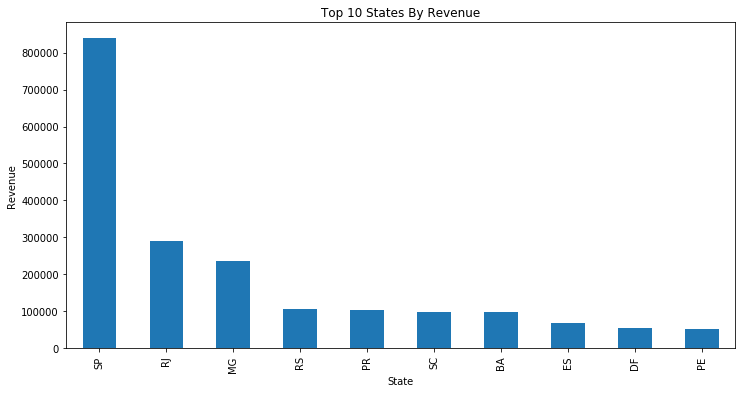

In [10]:
plt.figure(figsize = (12,6))
state_revenue.head(10).plot(kind = 'bar')
plt.title('Top 10 States By Revenue')
plt.xlabel('State')
plt.ylabel('Revenue')
plt.show()

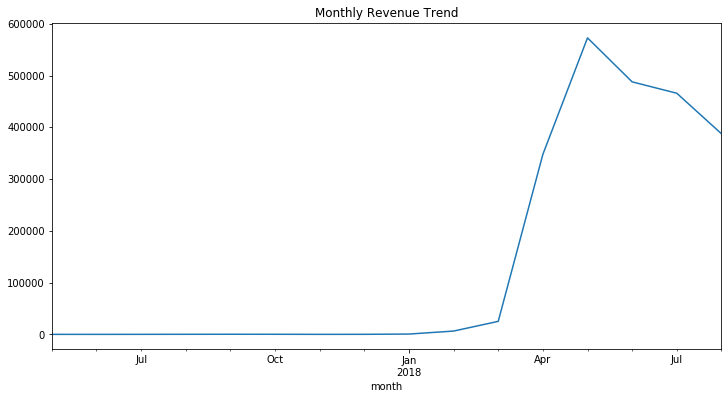

In [11]:
merged['month'] = merged['order_purchase_timestamp'].dt.to_period('M')
monthly_revenue = merged.groupby('month')['payment_value'].sum()

monthly_revenue.plot(figsize=(12,6))
plt.title('Monthly Revenue Trend')
plt.show()

In [12]:
customer_summary = merged.groupby('customer_unique_id').agg({'payment_value':'sum','order_id':'nunique'}).reset_index()
customer_summary.columns = ['customer_unique_id','total_spend','total_orders']
customer_summary['segment'] = pd.cut(customer_summary['total_spend'],bins=[0,100,500,1000,100000],labels = ['Low','Medium','High','VIP'])

In [13]:
customer_summary.head()

,customer_unique_id,total_spend,total_orders,segment
0,0000366f3b9a7992bf8c76cfdf3221e2,141.90,1,Medium
1,000ec5bff359e1c0ad76a81a45cb598f,27.75,1,Low
2,00172711b30d52eea8b313a7f2cced02,122.07,1,Medium
3,001928b561575b2821c92254a2327d06,329.62,1,Medium
4,0019e8c501c85848ac0966d45226fa1d,197.27,1,Medium


In [14]:
final = pd.merge(merged, customer_summary, on = 'customer_unique_id', how = 'inner')

In [15]:
final.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,month,total_spend,total_orders,segment
0,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,2018-07,141.46,1,Medium
1,40c5e18f7d112b59b3e5113a59a905b3,67407057a7d5ee17d1cd09523f484d13,delivered,2018-06-11 10:25:52,2018-06-11 10:58:32,2018-06-14 13:03:00,2018-06-19 00:31:13,2018-07-16 00:00:00,7cfba6e55439cae3fd2479d62fafe67f,22240,...,87bed0b5fb6856c9328d5e60df70546a,5,super recomento,Entrega antes da data marcada. Excelente,2018-06-20 00:00:00,2018-06-20 13:12:42,2018-06,128.68,1,Medium
2,86674ccaee19790309333210917b2c7d,1b338293f35549b5e480b9a3d7bbf3cd,delivered,2018-08-09 11:37:35,2018-08-09 14:35:19,2018-08-10 14:34:00,2018-08-14 18:51:47,2018-08-22 00:00:00,8b8028d453a01986b48c4271cc341475,14500,...,ebd3c6f3c54ee7cbdecefd57d5d57d1e,5,super recomendo,estou satisfeito,2018-08-15 00:00:00,2018-08-18 16:12:50,2018-08,135.82,1,Medium
3,f913d229653fdd809c249ed98ab6b754,e1365d7b227b247b6bc0931771885eaf,delivered,2018-04-30 02:18:32,2018-04-30 03:00:14,2018-04-30 13:54:00,2018-05-08 17:53:51,2018-05-24 00:00:00,66c70ed7726abccfbee61a9a39de15c5,90050,...,ff25eee85259b7a0991f9643a0b6dc34,5,Ótimo,Mais uma ve satisfeito,2018-05-09 00:00:00,2018-05-10 01:17:48,2018-04,137.45,1,Medium
4,aee682982e18eb4714ce9f97b15af5e2,8858442ea4d5dc5bb9e118e8f728095d,delivered,2018-07-09 18:46:28,2018-07-11 03:45:45,2018-07-11 15:01:00,2018-07-12 18:14:35,2018-07-18 00:00:00,3edcab192482e9871c17b34cf98c3996,33820,...,7a48dff7ae9e5a6d9187517daa9d9908,5,Muito bom,"Gostei bastante mas,a fragrância e mais fraca",2018-07-13 00:00:00,2018-07-17 16:31:39,2018-07,254.27,2,Medium


In [16]:
final.groupby('segment').count()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,product_width_cm,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,month,total_spend,total_orders
segment,,,,,,,,,,,,,,,,,,,,,
Low,4090,4090,4090,4090,4090,4090,4090,4090,4090,4090,...,4090,4090,4090,4090,4090,4090,4090,4090,4090,4090
Medium,5506,5506,5506,5506,5506,5506,5506,5506,5506,5506,...,5506,5506,5506,5506,5506,5506,5506,5506,5506,5506
High,1068,1068,1068,1068,1068,1068,1068,1068,1068,1068,...,1068,1068,1068,1068,1068,1068,1068,1068,1068,1068
VIP,922,922,922,922,922,922,922,922,922,922,...,922,922,922,922,922,922,922,922,922,922


## Exporting to CSV

In [19]:
final.to_csv('../data/final_tableau_dataset.csv',index=False)

In [18]:
final.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,month,total_spend,total_orders,segment
0,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,47813,...,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08 00:00:00,2018-08-08 18:37:50,2018-07,141.46,1,Medium
1,40c5e18f7d112b59b3e5113a59a905b3,67407057a7d5ee17d1cd09523f484d13,delivered,2018-06-11 10:25:52,2018-06-11 10:58:32,2018-06-14 13:03:00,2018-06-19 00:31:13,2018-07-16 00:00:00,7cfba6e55439cae3fd2479d62fafe67f,22240,...,87bed0b5fb6856c9328d5e60df70546a,5,super recomento,Entrega antes da data marcada. Excelente,2018-06-20 00:00:00,2018-06-20 13:12:42,2018-06,128.68,1,Medium
2,86674ccaee19790309333210917b2c7d,1b338293f35549b5e480b9a3d7bbf3cd,delivered,2018-08-09 11:37:35,2018-08-09 14:35:19,2018-08-10 14:34:00,2018-08-14 18:51:47,2018-08-22 00:00:00,8b8028d453a01986b48c4271cc341475,14500,...,ebd3c6f3c54ee7cbdecefd57d5d57d1e,5,super recomendo,estou satisfeito,2018-08-15 00:00:00,2018-08-18 16:12:50,2018-08,135.82,1,Medium
3,f913d229653fdd809c249ed98ab6b754,e1365d7b227b247b6bc0931771885eaf,delivered,2018-04-30 02:18:32,2018-04-30 03:00:14,2018-04-30 13:54:00,2018-05-08 17:53:51,2018-05-24 00:00:00,66c70ed7726abccfbee61a9a39de15c5,90050,...,ff25eee85259b7a0991f9643a0b6dc34,5,Ótimo,Mais uma ve satisfeito,2018-05-09 00:00:00,2018-05-10 01:17:48,2018-04,137.45,1,Medium
4,aee682982e18eb4714ce9f97b15af5e2,8858442ea4d5dc5bb9e118e8f728095d,delivered,2018-07-09 18:46:28,2018-07-11 03:45:45,2018-07-11 15:01:00,2018-07-12 18:14:35,2018-07-18 00:00:00,3edcab192482e9871c17b34cf98c3996,33820,...,7a48dff7ae9e5a6d9187517daa9d9908,5,Muito bom,"Gostei bastante mas,a fragrância e mais fraca",2018-07-13 00:00:00,2018-07-17 16:31:39,2018-07,254.27,2,Medium
